# 04. Treatment, Outcome, Estimand, Population

A causal question becomes operational only when four pieces are explicit:

1. **Treatment**: what action, policy, exposure, or intervention is being compared?
2. **Outcome**: what result is measured, and over what time horizon?
3. **Estimand**: what causal quantity summarizes the comparison?
4. **Population**: which units does the answer apply to?

Without these pieces, phrases like "the coupon worked," "the AI assistant helped," or "the ranking model increased revenue" are too vague. They may sound causal, but they do not yet define a causal target.

This lecture uses a promotion example where the same intervention has different answers depending on the outcome and population. A coupon can increase conversion, increase revenue, reduce profit overall, and still increase profit for a carefully chosen segment. All of those statements can be true at the same time because they refer to different estimands.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Define the treatment strategy, comparator, outcome, estimand, and target population for an applied causal question.
2. Explain why "the effect" is incomplete without specifying the estimand.
3. Distinguish outcome metrics from causal contrasts.
4. Compare effects across different target populations.
5. Understand why the same treatment can have different business interpretations for conversion, revenue, profit, and risk outcomes.
6. Write a compact estimand card that turns a vague request into an analyzable causal question.
7. Recognize post-treatment events that must be addressed before analysis.


## 1. From Vague Question to Estimand

A vague business question:

> Does a 10% coupon work?

A causal version:

> Among active customers eligible for a promotion at the start of the campaign, what is the average effect of sending a 10% coupon versus sending no coupon on 14-day contribution profit?

This version is better because it specifies:

| Component | Example |
|---|---|
| Unit | Customer |
| Population | Active customers eligible for the promotion at campaign start |
| Treatment strategy | Send a 10% coupon now |
| Comparator | Send no coupon now |
| Time zero | Moment campaign assignment is made |
| Outcome | 14-day contribution profit |
| Causal contrast | Average difference in potential outcomes |

Target-trial thinking uses a similar discipline. Hernán and Robins (2016) describe a target-trial protocol through components such as eligibility criteria, treatment strategies, assignment, follow-up, outcome, causal contrast, and analysis plan. The estimand framework similarly emphasizes that the target of estimation must be stated before design and analysis decisions are made (Mitroiu et al., 2020; Polito et al., 2024).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 115)
pd.set_option("display.precision", 3)


In [2]:
estimand_components = pd.DataFrame(
    [
        {
            "component": "Population",
            "question": "Which units are included?",
            "coupon_example": "Active customers eligible for a promotion at campaign start",
        },
        {
            "component": "Treatment",
            "question": "What action is assigned?",
            "coupon_example": "Send a 10% coupon immediately",
        },
        {
            "component": "Comparator",
            "question": "What alternative action is compared against treatment?",
            "coupon_example": "Send no coupon immediately",
        },
        {
            "component": "Outcome",
            "question": "What variable is measured, and when?",
            "coupon_example": "14-day purchase, revenue, contribution profit, or refund indicator",
        },
        {
            "component": "Causal contrast",
            "question": "How are potential outcomes summarized?",
            "coupon_example": "Average difference, risk ratio, relative lift, NNT, or policy value",
        },
        {
            "component": "Post-treatment events",
            "question": "What events after assignment change interpretation?",
            "coupon_example": "Unsubscribes, returns, stockouts, alternative discounts, or missing tracking",
        },
    ]
)

estimand_components


,component,question,coupon_example
0,Population,Which units are included?,Active customers eligible for a promotion at campaign start
1,Treatment,What action is assigned?,Send a 10% coupon immediately
2,Comparator,What alternative action is compared against treatment?,Send no coupon immediately
3,Outcome,"What variable is measured, and when?","14-day purchase, revenue, contribution profit, or refund indicator"
4,Causal contrast,How are potential outcomes summarized?,"Average difference, risk ratio, relative lift, NNT, or policy value"
5,Post-treatment events,What events after assignment change interpretation?,"Unsubscribes, returns, stockouts, alternative discounts, or missing tracking"


### Discussion

The estimand is the target. The estimator is the method used to learn the target. The estimate is the number produced by the method.

Do not start with "we will run regression" or "we will fit causal forest." Start with the estimand. A method is only appropriate relative to a target.

A useful habit is to say:

> We want to estimate **this causal contrast** between **these two treatment strategies** for **this population** on **this outcome** over **this time horizon**.


## 2. Mathematical Template

Let $S_i = 1$ indicate that unit $i$ belongs to the target population. Let $A_i = 1$ denote treatment and $A_i = 0$ denote control.

For a binary treatment, define potential outcomes:

$$
Y_i(1) = \text{outcome for unit } i \text{ under treatment}
$$

$$
Y_i(0) = \text{outcome for unit } i \text{ under control}
$$

A common estimand is the average treatment effect in the target population:

$$
\psi = E[Y(1) - Y(0) \mid S = 1]
$$

This single equation still hides many choices. What is $Y$? Who has $S=1$? What exactly is treatment? What exactly is control? Are we using a difference, ratio, risk difference, or decision value?

The notation is compact, but the practical work is in the definitions.


In [3]:
def estimand_card(
    *,
    population,
    treatment,
    comparator,
    outcome,
    horizon,
    contrast,
    decision,
):
    return pd.DataFrame(
        [
            {
                "population": population,
                "treatment": treatment,
                "comparator": comparator,
                "outcome": outcome,
                "horizon": horizon,
                "contrast": contrast,
                "decision": decision,
                "question": (
                    f"Among {population}, what is the {contrast} of {treatment} "
                    f"versus {comparator} on {outcome} over {horizon}?"
                ),
            }
        ]
    )

estimand_card(
    population="active customers eligible for promotion assignment at campaign start",
    treatment="sending a 10% coupon immediately",
    comparator="sending no coupon immediately",
    outcome="contribution profit per customer",
    horizon="14 days after assignment",
    contrast="average treatment effect",
    decision="decide whether to launch, target, redesign, or stop the coupon campaign",
)


,population,treatment,comparator,outcome,horizon,contrast,decision,question
0,active customers eligible for promotion assignment at campaign start,sending a 10% coupon immediately,sending no coupon immediately,contribution profit per customer,14 days after assignment,average treatment effect,"decide whether to launch, target, redesign, or stop the coupon campaign","Among active customers eligible for promotion assignment at campaign start, what is the average treatment effec..."


### Discussion

This card is intentionally plain. It is a forcing function. If a team cannot fill it out, the causal question is not ready.

In real work, this card also prevents metric drift. A team may start by asking about profit, then celebrate conversion lift after discovering that profit did not improve. That may be fine as exploratory analysis, but it is not the same estimand.


## 3. A Synthetic Promotion Dataset

We will simulate a customer promotion experiment-like setting. Each customer has:

- prior order history;
- tenure;
- price sensitivity;
- brand affinity;
- expected basket value;
- gross margin rate.

The treatment is a 10% coupon. The comparator is no coupon. We will study several outcomes over 14 days:

- purchase conversion;
- revenue;
- contribution profit;
- refund occurrence.

The data are synthetic, so we can inspect true potential outcomes. In real data, only one outcome would be observed per customer.


In [4]:
rng = np.random.default_rng(2027)
n_customers = 50_000

prior_orders = rng.poisson(lam=3.0, size=n_customers)
tenure_months = np.clip(rng.gamma(shape=2.5, scale=8, size=n_customers), 1, 60)
price_sensitivity = np.clip(
    rng.beta(a=2.2, b=2.8, size=n_customers)
    + 0.14 * (prior_orders == 0)
    - 0.004 * tenure_months,
    0,
    1,
)
brand_affinity = np.clip(
    rng.normal(loc=0, scale=1, size=n_customers)
    + 0.10 * prior_orders
    - 0.70 * price_sensitivity,
    -3,
    3,
)
basket_value = np.exp(
    3.45
    + 0.12 * prior_orders
    + 0.18 * brand_affinity
    + rng.normal(loc=0, scale=0.35, size=n_customers)
)
gross_margin_rate = np.clip(
    0.42
    - 0.12 * price_sensitivity
    + 0.03 * brand_affinity
    + rng.normal(loc=0, scale=0.04, size=n_customers),
    0.12,
    0.65,
)

# Purchase probability under no coupon and under coupon.
logit_purchase_no_coupon = (
    -1.95
    + 0.42 * np.log1p(prior_orders)
    + 0.02 * tenure_months
    + 0.85 * brand_affinity
    - 0.65 * price_sensitivity
)
coupon_logit_lift = 0.12 + 1.25 * price_sensitivity - 0.26 * brand_affinity

p_purchase_no_coupon = expit(logit_purchase_no_coupon)
p_purchase_coupon = expit(logit_purchase_no_coupon + coupon_logit_lift)

# Realized potential outcomes for purchase.
purchase_no_coupon = rng.binomial(n=1, p=p_purchase_no_coupon)
purchase_coupon = rng.binomial(n=1, p=p_purchase_coupon)

revenue_no_coupon = purchase_no_coupon * basket_value
revenue_coupon = purchase_coupon * basket_value * 0.90

profit_no_coupon = purchase_no_coupon * basket_value * gross_margin_rate
profit_coupon = purchase_coupon * basket_value * (gross_margin_rate - 0.10)

refund_probability_no_coupon = expit(-3.30 + 1.10 * price_sensitivity - 0.45 * brand_affinity)
refund_probability_coupon = expit(-3.15 + 1.30 * price_sensitivity - 0.35 * brand_affinity)
refund_no_coupon = rng.binomial(n=1, p=refund_probability_no_coupon) * purchase_no_coupon
refund_coupon = rng.binomial(n=1, p=refund_probability_coupon) * purchase_coupon

# Historical assignment: coupons are more likely for price-sensitive and lower-affinity customers.
coupon_probability = expit(
    -1.0
    + 1.5 * price_sensitivity
    - 0.35 * brand_affinity
    + 0.15 * (prior_orders == 0)
)
coupon = rng.binomial(n=1, p=coupon_probability)

customers = pd.DataFrame(
    {
        "prior_orders": prior_orders,
        "tenure_months": tenure_months,
        "price_sensitivity": price_sensitivity,
        "brand_affinity": brand_affinity,
        "basket_value": basket_value,
        "gross_margin_rate": gross_margin_rate,
        "coupon": coupon,
        "purchase_14d": np.where(coupon == 1, purchase_coupon, purchase_no_coupon),
        "revenue_14d": np.where(coupon == 1, revenue_coupon, revenue_no_coupon),
        "profit_14d": np.where(coupon == 1, profit_coupon, profit_no_coupon),
        "refund_14d": np.where(coupon == 1, refund_coupon, refund_no_coupon),
        # Simulation-only potential outcomes.
        "_purchase_no_coupon": purchase_no_coupon,
        "_purchase_coupon": purchase_coupon,
        "_revenue_no_coupon": revenue_no_coupon,
        "_revenue_coupon": revenue_coupon,
        "_profit_no_coupon": profit_no_coupon,
        "_profit_coupon": profit_coupon,
        "_refund_no_coupon": refund_no_coupon,
        "_refund_coupon": refund_coupon,
        "_p_purchase_no_coupon": p_purchase_no_coupon,
        "_p_purchase_coupon": p_purchase_coupon,
    }
)

customers.head()


,prior_orders,tenure_months,price_sensitivity,brand_affinity,basket_value,gross_margin_rate,coupon,purchase_14d,revenue_14d,profit_14d,...,_purchase_no_coupon,_purchase_coupon,_revenue_no_coupon,_revenue_coupon,_profit_no_coupon,_profit_coupon,_refund_no_coupon,_refund_coupon,_p_purchase_no_coupon,_p_purchase_coupon
0,0,21.995,0.319,-1.409,20.840,0.440,0,0,0.000,0.000,...,0,0,0.000,0.000,0.000,0.000,0,0,0.051,0.116
1,1,10.535,0.340,-1.357,52.166,0.333,0,0,0.000,0.000,...,0,0,0.000,0.000,0.000,0.000,0,0,0.056,0.127
2,3,16.154,0.521,0.528,39.641,0.339,0,1,39.641,13.431,...,1,1,39.641,35.677,13.431,9.467,0,1,0.282,0.425
3,2,11.865,0.672,-1.098,48.588,0.272,0,0,0.000,0.000,...,0,0,0.000,0.000,0.000,0.000,0,0,0.068,0.202
4,0,6.802,0.563,-0.678,21.490,0.357,0,0,0.000,0.000,...,0,1,0.000,19.341,0.000,5.526,0,0,0.060,0.147


### What This Simulation Represents

The coupon has two opposing forces:

1. It can increase purchase probability, especially among price-sensitive customers.
2. It reduces margin on purchases because the business gives up 10% of the basket value.

Therefore, the coupon can increase conversion while reducing profit. That is not a contradiction. It is a reminder that **outcome choice is part of the estimand**.


In [5]:
observed_summary = (
    customers.groupby("coupon")
    .agg(
        n=("purchase_14d", "size"),
        purchase_rate=("purchase_14d", "mean"),
        revenue_per_customer=("revenue_14d", "mean"),
        profit_per_customer=("profit_14d", "mean"),
        refund_rate=("refund_14d", "mean"),
        mean_price_sensitivity=("price_sensitivity", "mean"),
        mean_brand_affinity=("brand_affinity", "mean"),
    )
    .rename(index={0: "No coupon", 1: "Coupon"})
)

observed_summary


,n,purchase_rate,revenue_per_customer,profit_per_customer,refund_rate,mean_price_sensitivity,mean_brand_affinity
coupon,,,,,,,
No coupon,30340,0.290,17.565,7.231,0.012,0.339,0.197
Coupon,19660,0.333,15.852,4.978,0.024,0.414,-0.201


### Discussion

The observed table is not yet causal. The historical assignment process gives coupons more often to price-sensitive and lower-affinity customers. The treated and untreated groups differ before treatment.

The table is still useful: it describes what happened. But the causal estimands require potential-outcome contrasts.


## 4. Same Treatment, Different Outcomes

Now compute true finite-population causal effects using the simulation-only potential outcomes.

For a binary outcome like purchase, one common contrast is a risk difference:

$$
RD = P(Y(1)=1) - P(Y(0)=1)
$$

For a continuous outcome like profit, one common contrast is an average difference:

$$
ATE_{profit} = E[Profit(1) - Profit(0)]
$$

Both are average treatment effects, but they apply to different outcomes.


In [6]:
def mean_effect(treated_col, control_col, data=customers):
    return (data[treated_col] - data[control_col]).mean()

true_effects_by_outcome = pd.DataFrame(
    {
        "outcome": [
            "Purchase conversion",
            "Revenue per customer",
            "Contribution profit per customer",
            "Refund occurrence",
        ],
        "contrast": [
            "Risk difference",
            "Average difference",
            "Average difference",
            "Risk difference",
        ],
        "true_effect_coupon_minus_no_coupon": [
            mean_effect("_purchase_coupon", "_purchase_no_coupon"),
            mean_effect("_revenue_coupon", "_revenue_no_coupon"),
            mean_effect("_profit_coupon", "_profit_no_coupon"),
            mean_effect("_refund_coupon", "_refund_no_coupon"),
        ],
    }
)

true_effects_by_outcome


,outcome,contrast,true_effect_coupon_minus_no_coupon
0,Purchase conversion,Risk difference,0.099
1,Revenue per customer,Average difference,2.713
2,Contribution profit per customer,Average difference,-0.317
3,Refund occurrence,Risk difference,0.011


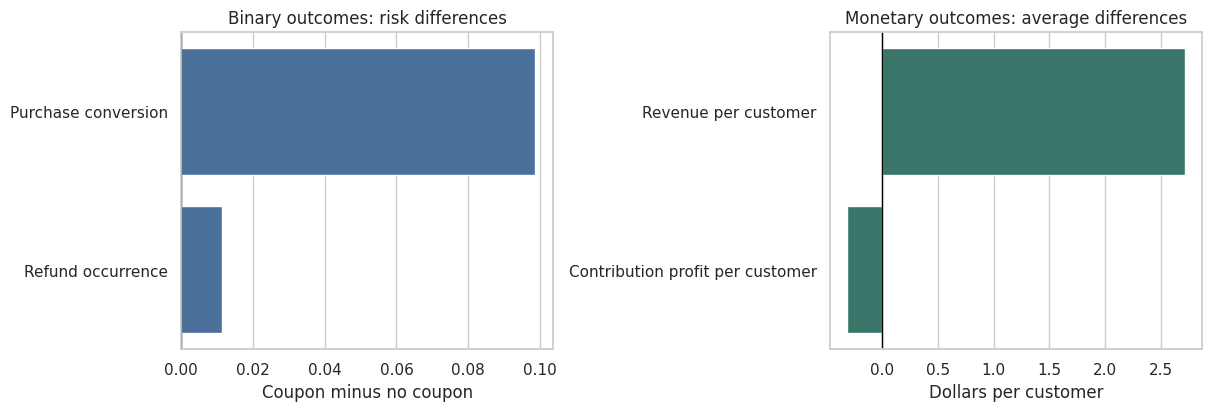

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(
    data=true_effects_by_outcome.loc[true_effects_by_outcome["outcome"].isin(["Purchase conversion", "Refund occurrence"])],
    x="true_effect_coupon_minus_no_coupon",
    y="outcome",
    color="#3b6ea8",
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Binary outcomes: risk differences")
axes[0].set_xlabel("Coupon minus no coupon")
axes[0].set_ylabel("")

sns.barplot(
    data=true_effects_by_outcome.loc[true_effects_by_outcome["outcome"].isin(["Revenue per customer", "Contribution profit per customer"])],
    x="true_effect_coupon_minus_no_coupon",
    y="outcome",
    color="#2f7f6f",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Monetary outcomes: average differences")
axes[1].set_xlabel("Dollars per customer")
axes[1].set_ylabel("")

plt.show()


### Discussion

The coupon increases purchase conversion and revenue per customer. But it slightly decreases contribution profit per customer overall. It also increases refunds slightly because more people buy, and because price-sensitive customers have a higher refund tendency in this synthetic world.

So, did the coupon "work"?

It depends on the estimand:

- If the goal is conversion lift, yes.
- If the goal is revenue lift, yes.
- If the goal is average contribution profit across all eligible customers, not in this simulation.
- If refund risk is a guardrail, the answer needs qualification.

This is exactly why outcome and causal contrast must be defined before analysis.


## 5. Same Outcome, Different Population

Now hold the outcome fixed as contribution profit and change the target population.

Define several populations:

- all eligible customers;
- high price-sensitivity customers;
- low price-sensitivity customers;
- new customers;
- loyal customers.

Each population answers a different decision question.


In [8]:
price_high_cutoff = customers["price_sensitivity"].quantile(0.70)
price_low_cutoff = customers["price_sensitivity"].quantile(0.30)

populations = {
    "All eligible customers": np.ones(len(customers), dtype=bool),
    "High price sensitivity": customers["price_sensitivity"] >= price_high_cutoff,
    "Low price sensitivity": customers["price_sensitivity"] <= price_low_cutoff,
    "New customers": customers["prior_orders"] == 0,
    "Loyal high-affinity customers": (customers["prior_orders"] >= 5) & (customers["brand_affinity"] > 0),
}

population_effects = []
for population_name, mask in populations.items():
    data = customers.loc[mask]
    population_effects.append(
        {
            "population": population_name,
            "share_of_customers": mask.mean(),
            "purchase_risk_difference": mean_effect("_purchase_coupon", "_purchase_no_coupon", data),
            "revenue_effect": mean_effect("_revenue_coupon", "_revenue_no_coupon", data),
            "profit_effect": mean_effect("_profit_coupon", "_profit_no_coupon", data),
            "refund_risk_difference": mean_effect("_refund_coupon", "_refund_no_coupon", data),
        }
    )

population_effects = pd.DataFrame(population_effects)
population_effects


,population,share_of_customers,purchase_risk_difference,revenue_effect,profit_effect,refund_risk_difference
0,All eligible customers,1.000,0.099,2.713,-0.317,0.011
1,High price sensitivity,0.300,0.159,5.889,0.777,0.020
2,Low price sensitivity,0.300,0.035,-0.780,-1.620,0.004
3,New customers,0.051,0.076,1.623,0.063,0.011
4,Loyal high-affinity customers,0.116,0.087,1.956,-1.983,0.008


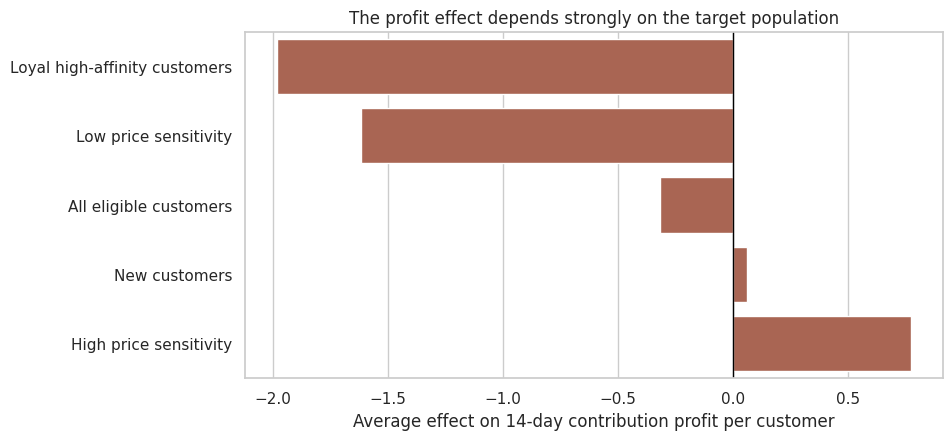

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = population_effects.sort_values("profit_effect")
sns.barplot(
    data=ordered,
    x="profit_effect",
    y="population",
    color="#b75d45",
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("The profit effect depends strongly on the target population")
ax.set_xlabel("Average effect on 14-day contribution profit per customer")
ax.set_ylabel("")
plt.show()


### Discussion

The coupon is not profitable on average for all eligible customers. It is profitable for high price-sensitivity customers and close to neutral for new customers. It is clearly unattractive for low price-sensitivity or loyal high-affinity customers.

This is not a contradiction. The estimand changed because the population changed:

$$
E[Profit(1) - Profit(0) \mid S = \text{high price sensitivity}]
$$

is not the same target as:

$$
E[Profit(1) - Profit(0) \mid S = \text{all eligible customers}]
$$

In industry, this is often the difference between "do not launch broadly" and "launch with targeting rules."


## 6. Same Outcome, Different Causal Contrast

Even with the same population and outcome, different contrasts can tell different stories.

For conversion, common contrasts include:

$$
Risk\ Difference = P(Y(1)=1) - P(Y(0)=1)
$$

$$
Risk\ Ratio = \frac{P(Y(1)=1)}{P(Y(0)=1)}
$$

$$
Relative\ Lift = \frac{P(Y(1)=1) - P(Y(0)=1)}{P(Y(0)=1)}
$$

For a positive conversion outcome, the number needed to treat is:

$$
NNT = \frac{1}{Risk\ Difference}
$$

when the risk difference is positive.


In [10]:
def conversion_contrasts(data):
    p1 = data["_purchase_coupon"].mean()
    p0 = data["_purchase_no_coupon"].mean()
    rd = p1 - p0
    return pd.Series(
        {
            "P_purchase_coupon": p1,
            "P_purchase_no_coupon": p0,
            "risk_difference": rd,
            "risk_ratio": p1 / p0,
            "relative_lift": rd / p0,
            "number_needed_to_treat": 1 / rd if rd > 0 else np.nan,
        }
    )

conversion_summary = pd.concat(
    {
        population_name: conversion_contrasts(customers.loc[mask])
        for population_name, mask in populations.items()
    },
    axis=1,
).T.reset_index(names="population")

conversion_summary


,population,P_purchase_coupon,P_purchase_no_coupon,risk_difference,risk_ratio,relative_lift,number_needed_to_treat
0,All eligible customers,0.361,0.262,0.099,1.376,0.376,10.130
1,High price sensitivity,0.359,0.200,0.159,1.795,0.795,6.292
2,Low price sensitivity,0.363,0.328,0.035,1.106,0.106,28.681
3,New customers,0.215,0.139,0.076,1.546,0.546,13.134
4,Loyal high-affinity customers,0.538,0.450,0.087,1.194,0.194,11.447


### Discussion

The risk difference tells us the absolute increase in conversion probability. The relative lift tells us the proportional increase relative to baseline conversion. The number needed to treat gives a rough operational interpretation: how many customers need the coupon to generate one additional purchaser.

For business decisions, absolute effects often matter more than relative effects. A large relative lift on a tiny baseline may not move profit. A modest relative lift on a large population may be valuable. The contrast should match the decision.


## 7. Post-Treatment Events and Guardrails

The estimand framework also asks what to do about events that happen after treatment assignment and affect interpretation. In clinical trials these are often called intercurrent events. In industry, the same idea appears constantly.

Examples:

- a customer receives a different coupon from another campaign;
- the item goes out of stock before the customer can purchase;
- a customer unsubscribes after receiving the email;
- a seller switches programs halfway through the measurement window;
- an AI support ticket is escalated to a human after the assistant fails;
- outcome tracking is lost because of cookie consent or app uninstall.

These are not nuisances to patch at the end. They help define the causal question.


In [11]:
post_treatment_events = pd.DataFrame(
    [
        {
            "event": "Customer receives another coupon during follow-up",
            "possible_strategy": "Treatment-policy strategy",
            "interpretation": "Estimate the effect of assigning the original coupon regardless of later campaign overlap.",
        },
        {
            "event": "Item is out of stock after coupon assignment",
            "possible_strategy": "Hypothetical strategy",
            "interpretation": "Ask what the effect would have been if stockouts had not occurred.",
        },
        {
            "event": "Customer unsubscribes after the coupon email",
            "possible_strategy": "Composite outcome strategy",
            "interpretation": "Define success to include purchase without unsubscribe, or treat unsubscribe as a harm outcome.",
        },
        {
            "event": "Customer does not open the coupon email",
            "possible_strategy": "Principal-stratum or per-protocol style question",
            "interpretation": "Ask about effects among would-open customers, or among customers who actually receive exposure.",
        },
        {
            "event": "Outcome is missing for app-uninstalled customers",
            "possible_strategy": "Missing-data strategy tied to estimand",
            "interpretation": "Decide whether missingness is part of the outcome, a censoring process, or requires sensitivity analysis.",
        },
    ]
)

post_treatment_events


,event,possible_strategy,interpretation
0,Customer receives another coupon during follow-up,Treatment-policy strategy,Estimate the effect of assigning the original coupon regardless of later campaign overlap.
1,Item is out of stock after coupon assignment,Hypothetical strategy,Ask what the effect would have been if stockouts had not occurred.
2,Customer unsubscribes after the coupon email,Composite outcome strategy,"Define success to include purchase without unsubscribe, or treat unsubscribe as a harm outcome."
3,Customer does not open the coupon email,Principal-stratum or per-protocol style question,"Ask about effects among would-open customers, or among customers who actually receive exposure."
4,Outcome is missing for app-uninstalled customers,Missing-data strategy tied to estimand,"Decide whether missingness is part of the outcome, a censoring process, or requires sensitivity analysis."


### Discussion

A common mistake is to define the treatment as "send a coupon," then later analyze only customers who opened the email. That changes the estimand. It no longer answers the effect of sending the coupon to eligible customers; it answers something closer to an effect among customers who complied with or were exposed to the treatment.

Neither question is automatically wrong. The problem is mixing them without saying so.


## 8. Writing Estimand Cards for Industry Projects

Estimand cards turn vague requests into analysis-ready targets. Below are three versions of a coupon question. Notice how each version implies a different decision.


In [12]:
cards = pd.concat(
    [
        estimand_card(
            population="all active customers eligible at campaign start",
            treatment="sending a 10% coupon immediately",
            comparator="sending no coupon immediately",
            outcome="purchase conversion",
            horizon="14 days",
            contrast="risk difference",
            decision="decide whether the campaign increases purchase behavior",
        ),
        estimand_card(
            population="all active customers eligible at campaign start",
            treatment="sending a 10% coupon immediately",
            comparator="sending no coupon immediately",
            outcome="contribution profit per customer",
            horizon="14 days",
            contrast="average treatment effect",
            decision="decide whether to launch broadly",
        ),
        estimand_card(
            population="customers in the top 30% of price sensitivity among eligible customers",
            treatment="sending a 10% coupon immediately",
            comparator="sending no coupon immediately",
            outcome="contribution profit per customer with refund rate as a guardrail",
            horizon="14 days",
            contrast="average treatment effect plus guardrail risk difference",
            decision="decide whether to target the campaign to a high-response segment",
        ),
    ],
    ignore_index=True,
)

cards[["population", "treatment", "comparator", "outcome", "horizon", "contrast", "decision"]]


,population,treatment,comparator,outcome,horizon,contrast,decision
0,all active customers eligible at campaign start,sending a 10% coupon immediately,sending no coupon immediately,purchase conversion,14 days,risk difference,decide whether the campaign increases purchase behavior
1,all active customers eligible at campaign start,sending a 10% coupon immediately,sending no coupon immediately,contribution profit per customer,14 days,average treatment effect,decide whether to launch broadly
2,customers in the top 30% of price sensitivity among eligible customers,sending a 10% coupon immediately,sending no coupon immediately,contribution profit per customer with refund rate as a guardrail,14 days,average treatment effect plus guardrail risk difference,decide whether to target the campaign to a high-response segment


### Discussion

The first estimand supports a growth or engagement story. The second supports a profitability story. The third supports a targeting story.

When stakeholders disagree, they are often arguing about the estimand without naming it. One person wants conversion lift. Another wants profit. Another wants to protect refund rates or unsubscribe rates. A good causal analysis makes these differences explicit.


## 9. Checklist Before Estimation

Before fitting a model, answer these questions:

1. **Population**: Who is eligible at time zero? Who is excluded?
2. **Treatment**: What exact action is assigned? Is it one action or several versions?
3. **Comparator**: What is the alternative? No action, old policy, delayed action, or another active treatment?
4. **Outcome**: What is measured? Is it primary, secondary, or a guardrail?
5. **Time horizon**: When does follow-up start and end?
6. **Contrast**: Difference, ratio, relative lift, quantile effect, policy value, or cost-benefit?
7. **Post-treatment events**: What happens with switching, noncompliance, missingness, stockouts, returns, or escalation?
8. **Decision**: What action will change depending on the estimate?
9. **Scale**: Is the estimand per user, per session, per seller, per store, per market, or total portfolio value?
10. **Equity and risk**: Are subgroup effects or guardrail outcomes part of the estimand?

This checklist is not bureaucracy. It is what prevents elegant estimation from answering the wrong question.


In [13]:
checklist = pd.DataFrame(
    [
        ("Population", "Active customers eligible at campaign start"),
        ("Treatment", "Send a 10% coupon immediately"),
        ("Comparator", "Send no coupon immediately"),
        ("Outcome", "14-day contribution profit per customer"),
        ("Contrast", "Average treatment effect"),
        ("Guardrail", "Refund risk difference and unsubscribe risk difference"),
        ("Decision", "Broad launch, targeted launch, redesign, or no launch"),
    ],
    columns=["component", "example_specification"],
)

checklist


,component,example_specification
0,Population,Active customers eligible at campaign start
1,Treatment,Send a 10% coupon immediately
2,Comparator,Send no coupon immediately
3,Outcome,14-day contribution profit per customer
4,Contrast,Average treatment effect
5,Guardrail,Refund risk difference and unsubscribe risk difference
6,Decision,"Broad launch, targeted launch, redesign, or no launch"


## 10. Key Takeaways

1. A causal estimand is not just "the effect." It is a specific causal contrast for a specific treatment, comparator, outcome, time horizon, and population.
2. The same intervention can help one outcome and hurt another.
3. The same intervention can be unattractive for the full population and attractive for a targeted subgroup.
4. Relative effects, absolute effects, and monetary effects answer different business questions.
5. Post-treatment events such as switching, noncompliance, stockouts, returns, and missing outcomes are part of estimand definition, not cleanup details.
6. Estimand cards are a practical way to align stakeholders before modeling begins.
7. Estimation methods should be chosen only after the estimand is clear.

## Preview of the Next Lecture

The next lecture focuses on average treatment effects. We will go deeper into ATE, ATT, ATC, subgroup effects, and how these quantities connect to business decisions.


## References

- Hernán, M. A., & Robins, J. M. (2016). Using big data to emulate a target trial when a randomized trial is not available. *American Journal of Epidemiology, 183*(8), 758-764. https://doi.org/10.1093/aje/kwv254. Access: open / DOI page.
- Mitroiu, M., Oude Rengerink, K., Teerenstra, S., Roes, K. C. B., & Grobbee, D. E. (2020). A narrative review of estimands in drug development and regulatory evaluation: Old wine in new barrels? *Trials, 21*, 671. https://doi.org/10.1186/s13063-020-04546-1. Access: open / DOI page.
- Polito, L., Liang, Q., Pal, N., Brandt, C., Wang, S. J., & He, K. (2024). Applying the estimand and target trial frameworks to external control analyses using observational data: A case study in the solid tumor setting. *Frontiers in Pharmacology, 15*, 1223858. https://doi.org/10.3389/fphar.2024.1223858. Access: open / DOI page.
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology, 66*(5), 688-701. https://doi.org/10.1037/h0037350. Access: publisher / DOI page.
